# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Analysis Parameters

In [3]:
# Image dataset
imageset = '../data/images_MtPleasant/'

# Model fit dataset
modelset = '../data/MtPleasant.pkl'

# Data save location
save_csv = '../data/results_MtPleasant/median_anom_summer_2019.csv'

# Image save location
save_image = '../data/results_MtPleasant/median_anom_summer_2019.png'

# Analysis year
year = 2019

# Load Data

In [4]:
models = pd.read_pickle(modelset)

In [5]:
models = models.dropna().copy()

In [12]:
def quality_check(breaks):
    # Returns 1 if breaks appear to appropriately placed 0 otherwise
    breaks_in_season = sum([br < 365 for br in breaks])
    if breaks_in_season == 5:
        return 1
    else:
        return 0

models['quality'] = models['breaks'].map(quality_check)

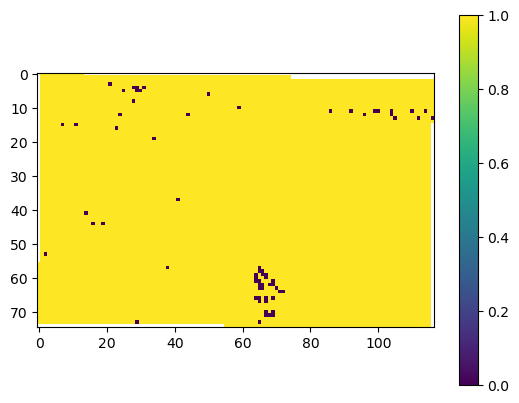

In [13]:
model_pivot = models[['lat','lon','quality']].pivot(index = 'lat', columns = 'lon')
plt.imshow(model_pivot)
plt.colorbar()

In [19]:
def break_count(breaks):
    # Returns 1 if breaks appear to appropriately placed 0 otherwise
    return sum([br < 400 for br in breaks])

models['break_count'] = models['breaks'].map(break_count)

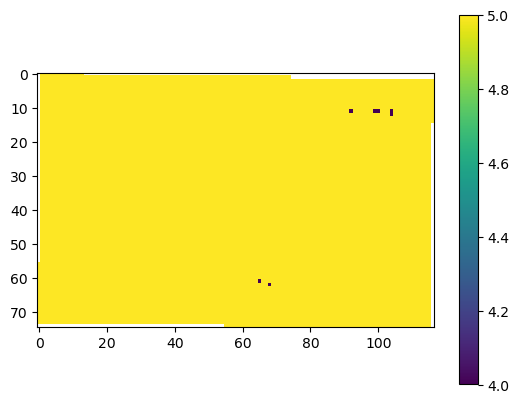

In [20]:
model_pivot = models[['lat','lon','break_count']].pivot(index = 'lat', columns = 'lon')
plt.imshow(model_pivot)
plt.colorbar()

In [21]:
mask = models['break_count'] == 4
models[mask]

,lat,lon,intercepts,slopes,breaks,quality,break_count
1379,11.0,92.0,"[-0.20023789723368754, -2.825224799273976, 1.8...","[0.0034972565099423165, 0.023660481564188013, ...","[64.0, 130.18685726009662, 161.7256564567969, ...",0,4
1386,11.0,99.0,"[-0.3410216820450789, -2.6786464336343974, 2.0...","[0.004902879768080076, 0.022699075454140058, -...","[64.0, 131.35530721436234, 161.84553017008034,...",0,4
1387,11.0,100.0,"[-0.3306204118435294, -2.798757925588536, 2.05...","[0.004799941139641107, 0.023660201873242925, -...","[64.0, 130.86444289435107, 161.6237036906067, ...",0,4
1391,11.0,104.0,"[-0.41035978749661234, -2.7119963098698654, 1....","[0.0056862424029430906, 0.023365451148924642, ...","[69.0, 130.1888877179761, 159.23184039888133, ...",0,4
1508,12.0,104.0,"[-0.38745005083074124, -3.1007423130976632, 1....","[0.005595037271280903, 0.02599981512322578, -0...","[64.0, 132.9733791739519, 157.6421702146519, 3...",0,4
7202,61.0,65.0,"[-0.09914502406737434, -2.6017978277830873, 1....","[0.0027301586294175492, 0.022763084314971028, ...","[33.0, 124.92697487119783, 156.78889063897995,...",0,4
7322,62.0,68.0,"[-0.07401700744218638, -2.6040360128938986, 1....","[0.0021097469102128352, 0.02257099724704934, -...","[33.0, 123.64928651974431, 158.1129921234994, ...",0,4


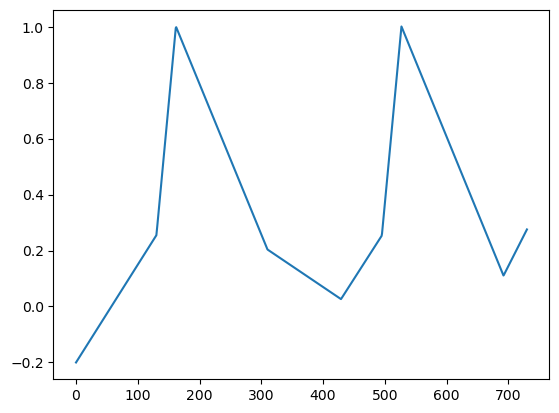

In [22]:
def model_predict(intercepts, slopes, breaks, value):
    if value < breaks[0]:
        return slopes[0]*value + intercepts[0]
    for i in range(len(breaks)-1):
        if breaks[i] <= value and value < breaks[i+1]:
            return slopes[i]*(value) + intercepts[i]
    return slopes[-1]*value + intercepts[-1]

X_grid = np.linspace(0, 365*2, 1000)
y_grid = [model_predict(models.loc[mask,'intercepts'].iloc[0],models.loc[mask,'slopes'].iloc[0],models.loc[mask,'breaks'].iloc[0],x) for x in X_grid]

plt.plot(X_grid, y_grid)

In [ ]:
band = 'EVI'
    
df = all_data.isel(lat=2, lon=91).to_pandas().reset_index().dropna()
    
# Extract day of year and year information from system index
df = add_doy_year(df)
    
year_mask = df['Year'] >= 2019
df = df.loc[year_mask]
    
# Normalizes data within year
df = normalize_VI(df, band)
    
# Removes outliers using a window method
df = window_remove_outliers(df, band, 'doy', 15)
    
#break_guesses = np.array()
    
# Normalize doy
#df, break_guesses = normalize_doy(df, break_guesses)
    
# Duplicate df to have 2 'years' worth of data
df = duplicate_doy(df)

In [ ]:
plt.plot(X_grid,y_grid)
plt.plot(df['doy'], df['EVI_nrml'], 'o')